In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
# ==========================================
# 2. TẢI CÓ TÍNH CHU KỲ (Periodic Workload)
# ==========================================
# Theo Hình 5d, biểu đồ chạy đến gần 250 phút để mô phỏng [cite: 281, 284]
t_periodic = np.arange(1, 251)

# Các tham số để tạo sóng hình sin:
w_p_t0 = 20000 # w_p(t_o): Giá trị lệch (Bias) - Mức tải nền trung bình của hệ thống [cite: 303, 305]
w_m = 20000  # w_m: Biên độ (Amplitude) - Sự chênh lệch giữa mức tải cao nhất và trung bình [cite: 303, 305]
p = 70          # p: Chu kỳ (Time period) - Cứ 70 phút thì lặp lại 1 vòng tải [cite: 303, 305]

# Áp dụng Công thức (4) trong bài báo: w_p(t) = w_p(t_o) + w_m * sin(2*t*pi / p) [cite: 305]
w_per = w_p_t0 + w_m * np.sin((2 * t_periodic * np.pi) / p)
w_per = np.round(w_per).astype(int) # Làm tròn thành số nguyên vì request không thể là số lẻ

In [8]:
# ==========================================
# 2. TẠO NHIỄU "RỒ GẦN" (ROUGH NOISE)
# ==========================================
# Kết hợp Sóng Sin và Nhiễu ngẫu nhiên để tạo đường răng cưa tự nhiên
np.random.seed(42) # Đặt seed để kết quả ổn định mỗi lần chạy

# a)  Sóng sin lớn:
periodic_max = 40 * np.sin(2 * np.pi * t_periodic / 60)

# b) Sóng sin nhỏ (Periodic Noise): Tạo chu kỳ lên/xuống nhỏ
periodic_min = 250 * np.sin(2 * np.pi * t_periodic / 5)

# c) Nhiễu ngẫu nhiên (Random Noise): Tạo các răng cưa nhỏ, sắc nhọn
# (Độ lệch chuẩn 800 tạo ra biến động vừa phải xung quanh đường xu hướng)
random_noise = np.random.normal(0, 20, size=len(t_periodic))


# c) Tổng hợp nhiễu rồ ghề
total_workload = w_per + periodic_max + periodic_min + random_noise

# Đảm bảo giá trị request là số nguyên (integer) và không bị âm
w_periodic = np.maximum(np.round(total_workload), 0).astype(int)

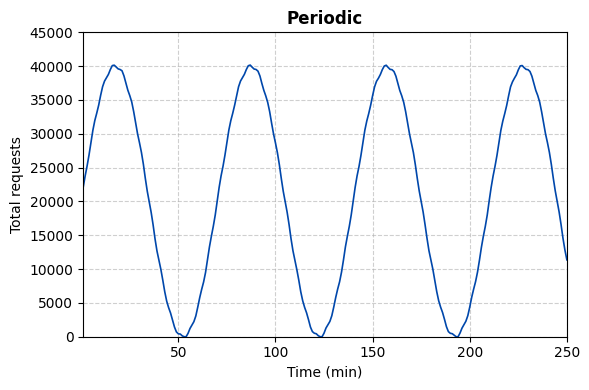

In [9]:

# ==========================================
# 3. VẼ BIỂU ĐỒ TRỰC QUAN (Giống Hình 5c và 5d) 
# ==========================================
plt.figure(figsize=(6, 4))
plt.plot(t_periodic, w_periodic, color='#0047AB', linewidth=1.2)
plt.title("Periodic", fontsize=12, fontweight='bold')
plt.xlabel("Time (min)", fontsize=10)
plt.ylabel("Total requests", fontsize=10)

plt.xlim(1, 250)
plt.ylim(0, 45000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Lưu ảnh
plt.savefig('../../workload_generation/data/periodic_workload.png', dpi=300)
plt.show()

In [10]:
# ==========================================
# 4. LƯU DỮ LIỆU ĐỂ DÙNG CHO MÔ HÌNH HỌC MÁY
# ==========================================
df_periodic = pd.DataFrame({'time': t_periodic, 'requests': w_periodic})

df_periodic.to_csv('../../workload_generation/data/periodic_workload.csv', index=False)
print("Đã tạo và lưu thành công")

Đã tạo và lưu thành công
